# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

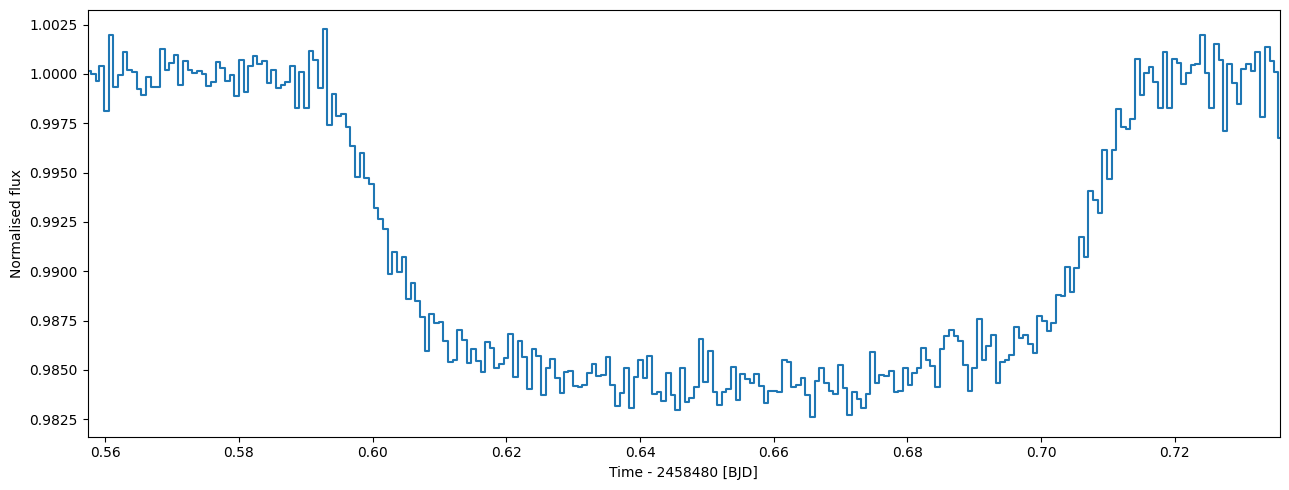

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

Global optimisation:   0%|          | 0/500 [00:00<?, ?it/s]

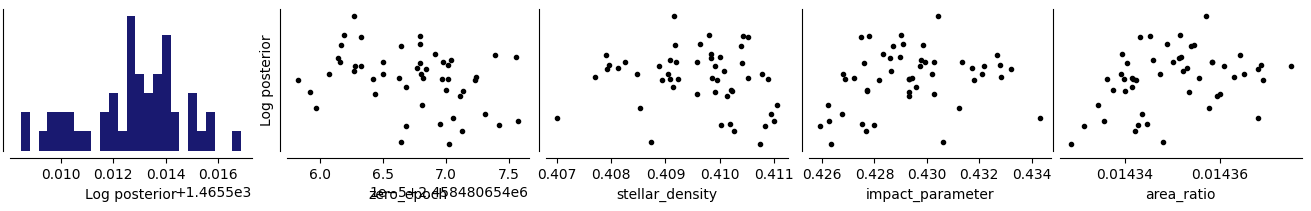

In [7]:
lpf.optimize_global(niter=500, npop=50)

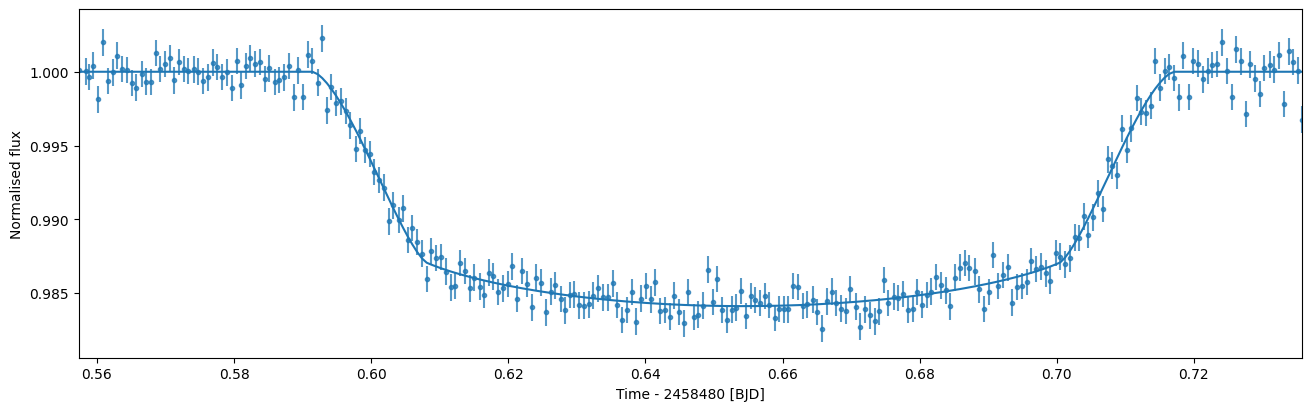

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling:   0%|          | 0/2 [00:00<?, ?it/s]

Run 1/2:   0%|          | 0/5000 [00:00<?, ?it/s]

Run 2/2:   0%|          | 0/5000 [00:00<?, ?it/s]

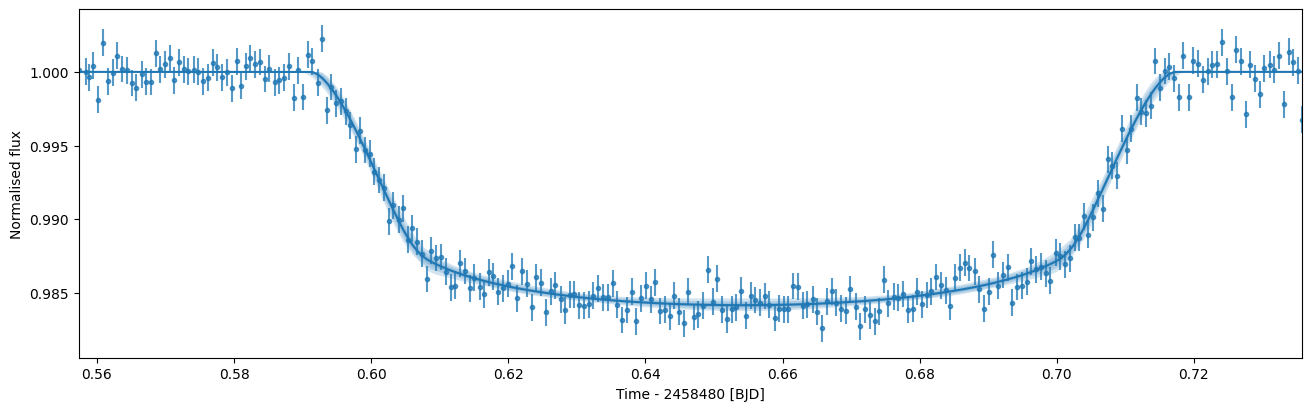

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

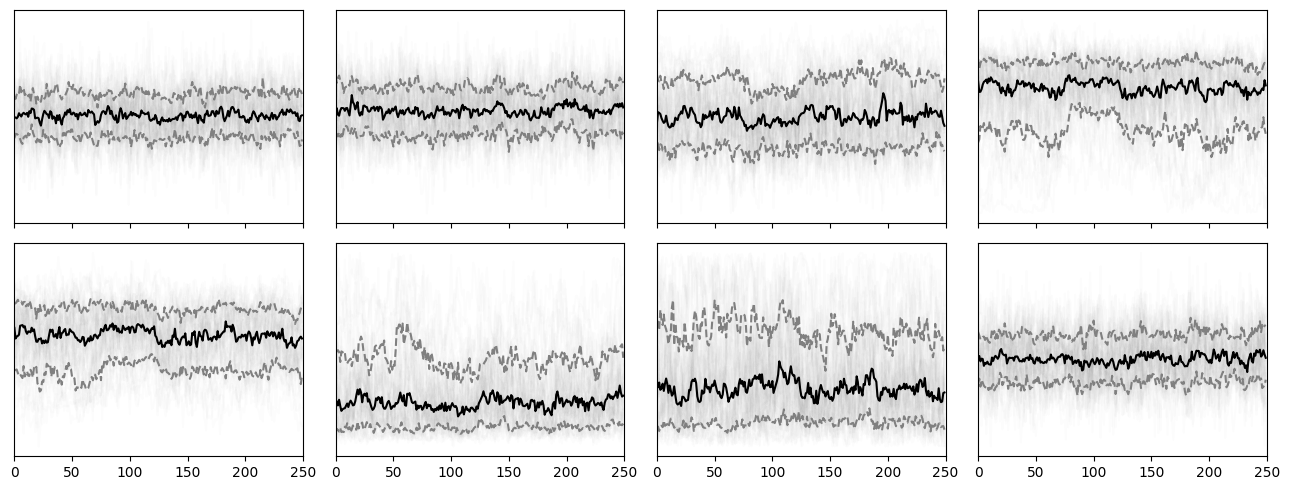

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

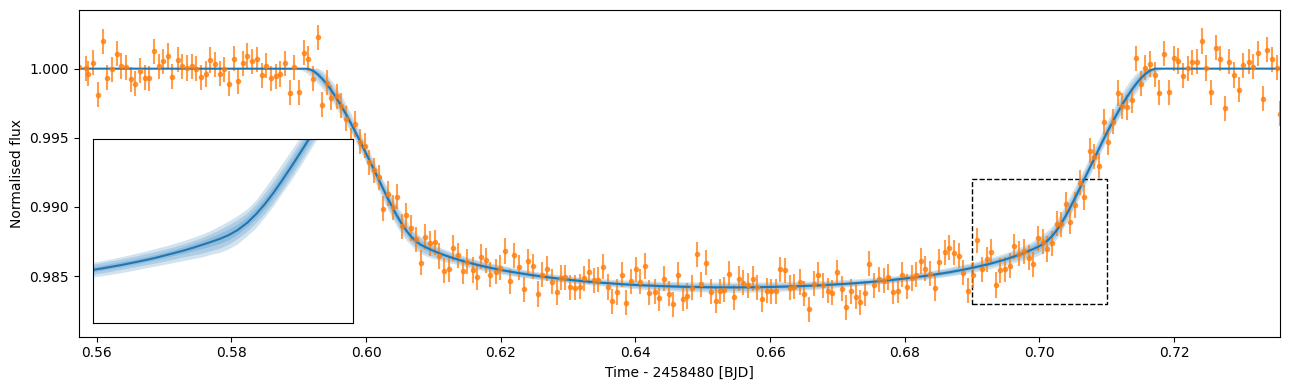

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4318,0.3504,0.0140,0.3017,3.5083e-01,-3.0410,0.1183,3.0049,1.4529,0.1258,0.0944
std,1.6066e-04,1.1140e-09,0.0351,0.1067,0.0004,0.1833,2.3764e-01,0.0190,0.0018,0.0814,0.0382,0.0010,0.0024
min,2.4585e+06,1.0914e+00,0.3294,0.0008,0.0125,0.0398,3.3175e-05,-3.1068,0.1120,2.7475,1.3608,0.1224,0.0863
25%,2.4585e+06,1.0914e+00,0.4059,0.2937,0.0137,0.1615,1.6127e-01,-3.0540,0.1171,2.9457,1.4248,0.1251,0.0926
50%,2.4585e+06,1.0914e+00,0.4295,0.3741,0.0140,0.2536,2.9799e-01,-3.0413,0.1185,3.0016,1.4457,0.1258,0.0942
75%,2.4585e+06,1.0914e+00,0.4565,0.4287,0.0143,0.3949,4.9452e-01,-3.0285,0.1196,3.0633,1.4749,0.1264,0.0962
max,2.4585e+06,1.0914e+00,0.5305,0.5744,0.0151,0.9980,9.9986e-01,-2.9619,0.1231,3.2207,1.5705,0.1304,0.1011


<Axes: >

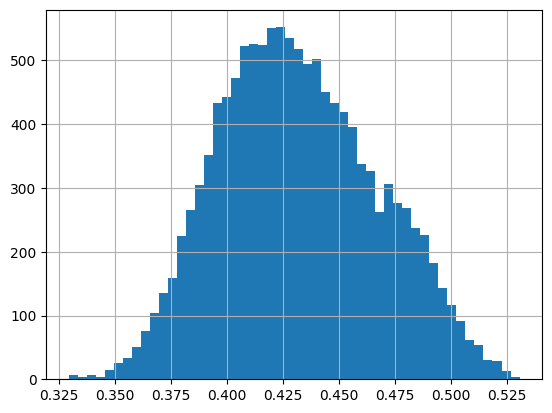

In [16]:
df.rho.hist(bins=50)

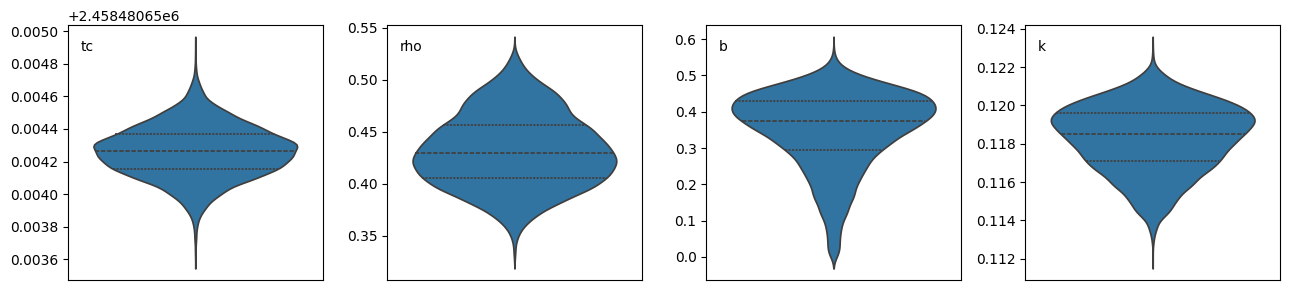

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

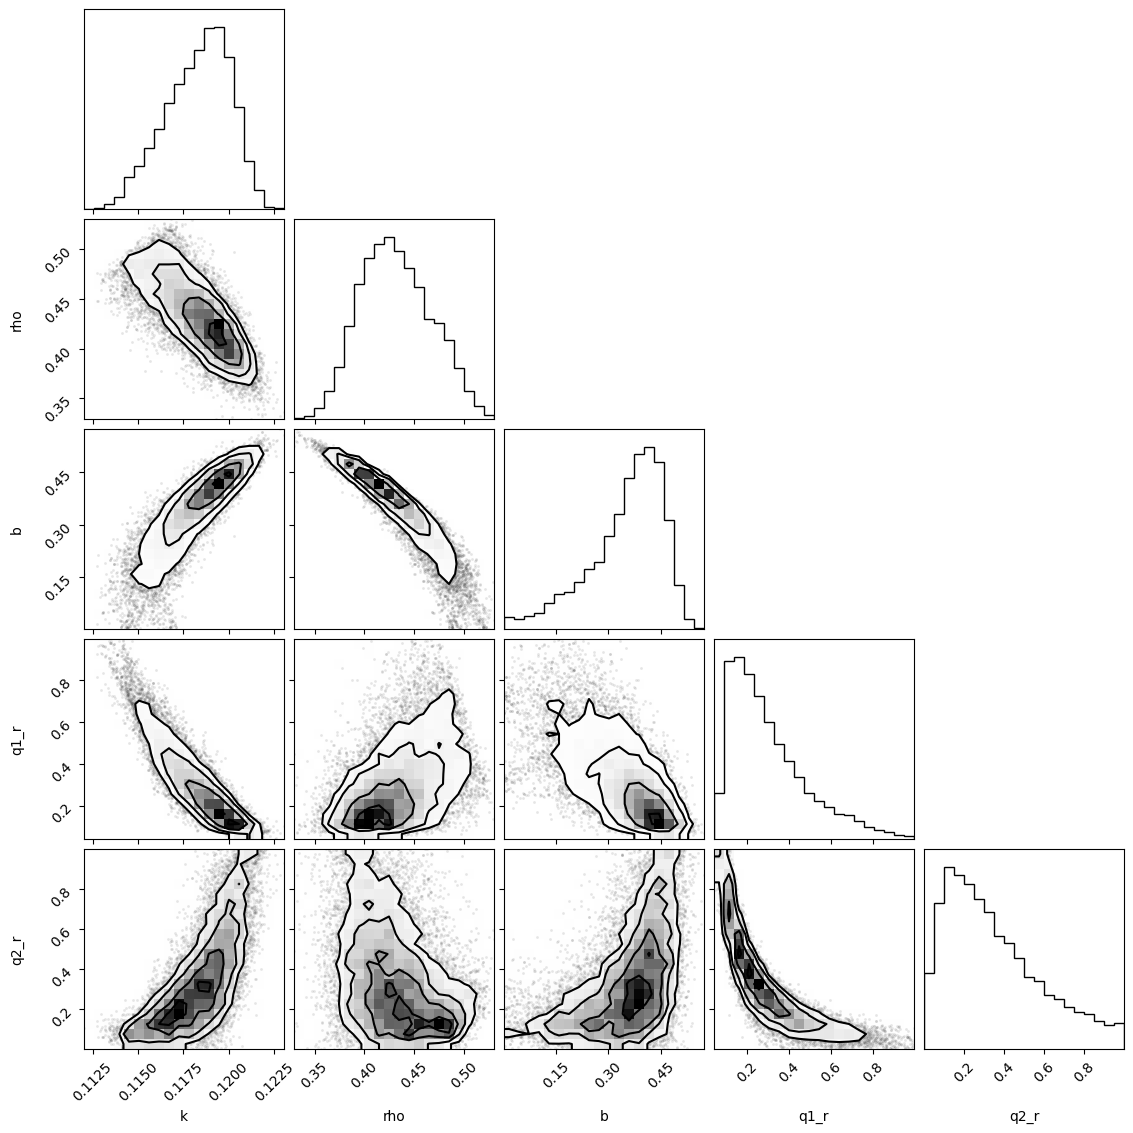

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

Rp = 1.811 (+0.024/-0.032) Rjup


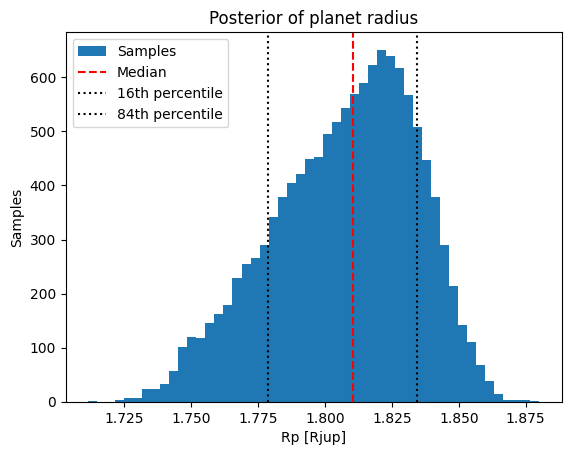

In [19]:
import numpy as np
import astropy.units as u
from astropy.constants import R_sun, R_jup


k = df["k"].values # Planet-star radius ratio

Rstar = 1.57 * R_sun # WASP-12 radius

Rp = k * Rstar # planet radius
Rp = Rp.to(R_jup)

median = np.median(Rp.value) # Median radius
p16 = np.percentile(Rp.value, 16) # 16th percentile
p84 = np.percentile(Rp.value, 84) # 84th percentilo

print(f"Rp = {median:.3f} (+{p84-median:.3f}/-{median-p16:.3f}) Rjup")

import matplotlib.pyplot as plt

plt.hist(Rp.value, bins=50, label="Samples")

plt.axvline(median, linestyle="--", color='red', label="Median")
plt.axvline(p16, linestyle=":", color='black', label="16th percentile")
plt.axvline(p84, linestyle=":", color='black', label="84th percentile")

plt.xlabel("Rp [Rjup]")
plt.ylabel("Samples")
plt.title("Posterior of planet radius")

plt.legend()
plt.show()

2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

rho = 0.295 (+0.017/-0.012) g/cm^3


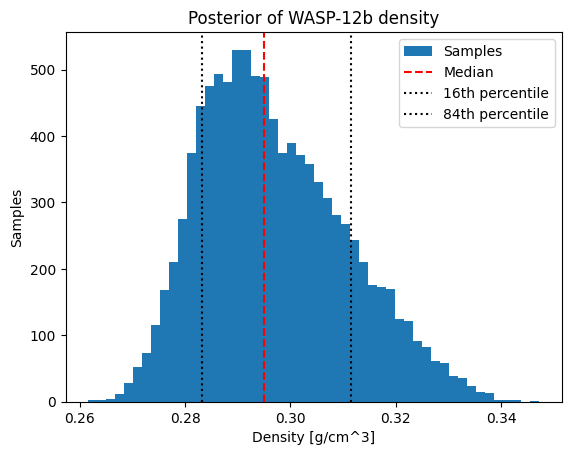

In [20]:
m_sini = np.load("m_sini_samples.npy") * u.M_jup # Loading the mass density 
k = df["k"].values # Planet-star radius ratio
Rstar = 1.57 * u.R_sun # WASP-12 radius 

Rp = k * Rstar # Planet radius
Rp = Rp.to(u.R_jup)

N = min(len(m_sini), len(Rp)) # Making sure both arrays have the same length
m_sini = m_sini[:N]
Rp = Rp[:N]

M = m_sini.to(u.kg)
R = Rp.to(u.m)

rho_p = (3 * M) / (4 * np.pi * R**3) # Planet's bulk density
rho_p = rho_p.to(u.g / u.cm**3)

median = np.median(rho_p.value) # Median bulk density
p16 = np.percentile(rho_p.value, 16) #16th percentile
p84 = np.percentile(rho_p.value, 84) #84th percentile

print(f"rho = {median:.3f} (+{p84-median:.3f}/-{median-p16:.3f}) g/cm^3")

plt.hist(rho_p.value, bins=50, label="Samples")

plt.axvline(median, linestyle="--", color='red', label="Median")
plt.axvline(p16, linestyle=":", color='black', label="16th percentile")
plt.axvline(p84, linestyle=":", color='black', label="84th percentile")

plt.xlabel("Density [g/cm^3]")
plt.ylabel("Samples")
plt.title("Posterior of WASP-12b density")

plt.legend()
plt.show()

3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- For transiting planets, the orbital inclination is close to 90º, so $sin \, i \approx 1$ and the RV minimum mass $m \, sin \, i$ is effectively equal to the true mass, removing the main degeneracy present in RV-only detections.

    Modelling RVs and photometry separately ignores correlations between parameters (such as stellar density and inclination), so a better approach is to perform a joint fit of both datasets within a single Bayesian framework, which provides more consistent parameter estimates, properly propagates uncertainties, and allows the inclusion of additional constraints like stellar models for improved accuracy.
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

- Based on its minimum mass and orbital period, WASP-12b was identified as a typical hot Jupiter, with a mass of about $1.41\,M_{\mathrm{Jup}}$ and an extremely short orbital period of $\sim 1.09$ days, implying a very close-in orbit. Adding the new information from its radius of about $1.81\,R_{\mathrm{Jup}}$ and its very low bulk density of about $0.295\,\mathrm{g\,cm^{-3}}$, it is clear that the planet is a highly inflated gas giant with an extended, low-gravity atmosphere composed mainly of hydrogen and helium, where strong stellar heating leads to atmospheric expansion, possible mass loss, and tidal deformation, making WASP-12b an extreme example of a bloated hot Jupiter undergoing significant interaction with its host star.

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- The stellar density derived from the transit modelling, $\rho_\star \approx 0.4337\,\rho_\odot$, is consistent with the theoretical expectation for a WASP-12-like star. Using typical stellar parameters for WASP-12, with a mass of $M_\star \sim 1.4\,M_\odot$ and a radius of $R_\star \sim 1.6\,R_\odot$, the theoretical density can be estimated as $\rho_\star \propto M_\star / R_\star^3 \approx 1.3/1.6^3 \approx 0.35\,\rho_\odot$. The transit-derived value is therefore somewhat higher but still of the same order of magnitude, indicating general consistency between the photometric constraints and stellar structure expectations. Small discrepancies can arise from degeneracies in the transit parameters, as well as assumptions such as circular orbits and the treatment of limb darkening, all of which can bias the inferred stellar density. Additionally, uncertainties in the independently assumed stellar properties propagate into the comparison.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

- The fact that these parameters are correlated means that the data does does not constrain each one independently. Instead, they are partly linked, so that changing one parameter can often be compensated by adjusting another without significantly changing how well the model fits the data. In practice, this means the observations constrain combinations of parameters rather than each parameter on its own. For example, if the impact parameter $b$ is changed, the stellar density $\rho_\star$ can adjust in a way that still reproduces a very similar transit shape. Because of these interdependencies, the posterior distributions are stretched and not circular, reflecting these degeneracies, and the uncertainties on each parameter become larger since they must include all the allowed correlated solutions rather than independent variations.


---
<center>&copy;2026 Hannu Parviainen</center>